In [1]:
# Cell 1: Install required libraries
!pip install scikit-learn pandas numpy matplotlib seaborn imbalanced-learn -q

In [2]:
# Cell 2: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, accuracy_score)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Cell 3: Load the German Credit Dataset (public dataset)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    'checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_account', 'employment', 'installment_rate', 'personal_status',
    'other_debtors', 'residence_since', 'property', 'age', 'other_installments',
    'housing', 'existing_credits', 'job', 'liable_people', 'telephone',
    'foreign_worker', 'target'
]

df = pd.read_csv(url, sep=' ', header=None, names=columns)

# Convert target: 1 = Good Credit, 2 = Bad Credit → remap to 0 = Good, 1 = Bad
df['target'] = df['target'].map({1: 0, 2: 1})

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset loaded!
Shape: (1000, 21)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,liable_people,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [4]:
# Cell 4: Basic info
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Distribution:")
print(df['target'].value_counts())
print(f"\nGood Credit (0): {(df['target']==0).sum()} | Bad Credit (1): {(df['target']==1).sum()}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   checking_account    1000 non-null   object
 1   duration            1000 non-null   int64 
 2   credit_history      1000 non-null   object
 3   purpose             1000 non-null   object
 4   credit_amount       1000 non-null   int64 
 5   savings_account     1000 non-null   object
 6   employment          1000 non-null   object
 7   installment_rate    1000 non-null   int64 
 8   personal_status     1000 non-null   object
 9   other_debtors       1000 non-null   object
 10  residence_since     1000 non-null   int64 
 11  property            1000 non-null   object
 12  age                 1000 non-null   int64 
 13  other_installments  1000 non-null   object
 14  housing             1000 non-null   object
 15  existing_credits    1000 non-null   int64 
 16  job        

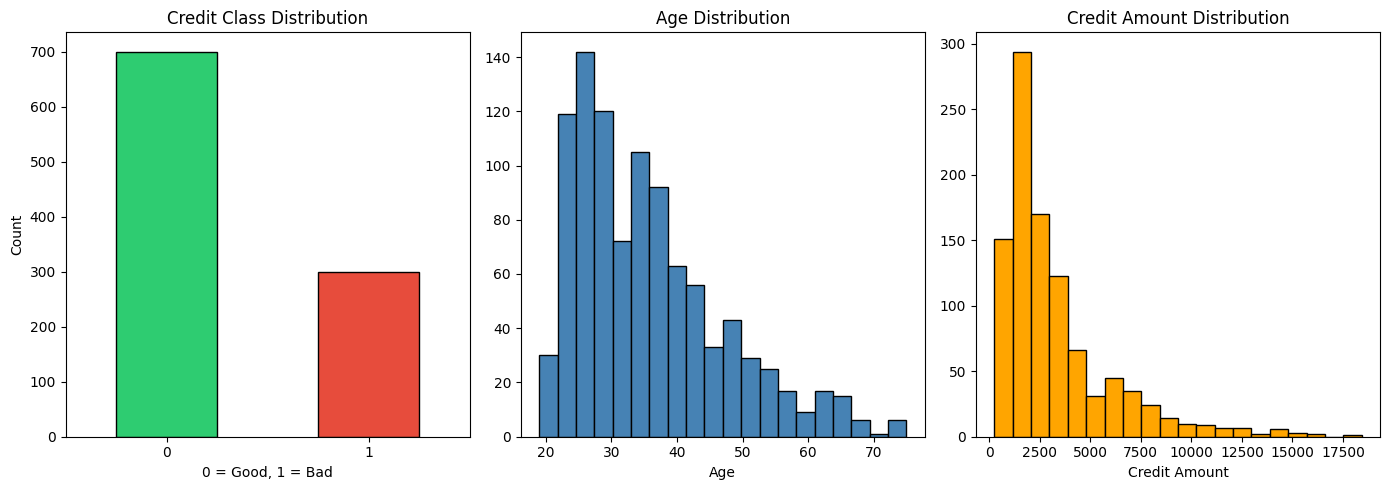

In [5]:
# Cell 5: Visualize target distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
df['target'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Credit Class Distribution')
plt.xlabel('0 = Good, 1 = Bad')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 3, 2)
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')

plt.subplot(1, 3, 3)
plt.hist(df['credit_amount'], bins=20, color='orange', edgecolor='black')
plt.title('Credit Amount Distribution')
plt.xlabel('Credit Amount')

plt.tight_layout()
plt.show()

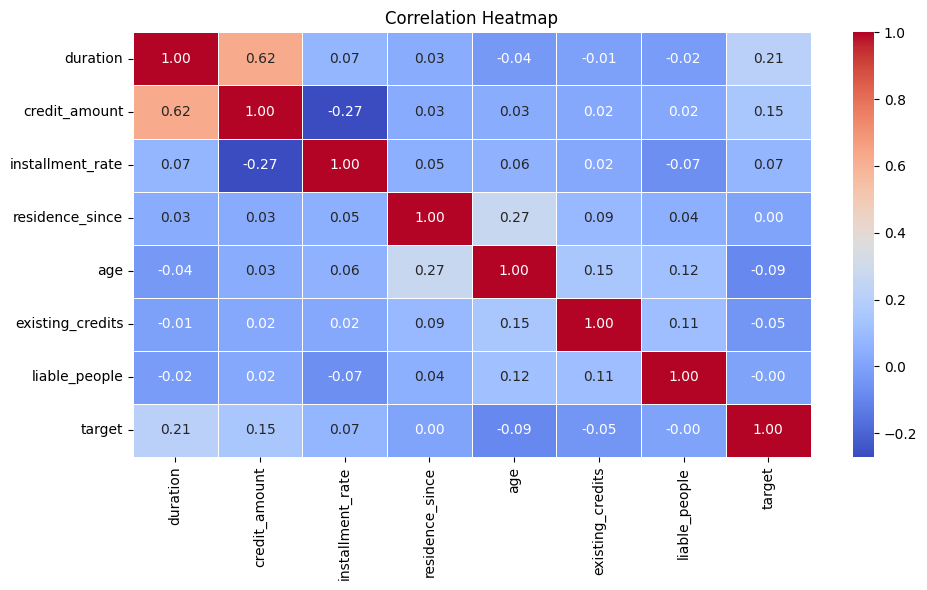

In [6]:
# Cell 6: Correlation heatmap (numerical only)
plt.figure(figsize=(10, 6))
num_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [7]:
# Cell 7: Encode categorical columns
df_encoded = df.copy()
le = LabelEncoder()

cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
print(f"Categorical Columns: {cat_cols}")

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("✅ Encoding done!")
df_encoded.head()

Categorical Columns: ['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installments', 'housing', 'job', 'telephone', 'foreign_worker']
✅ Encoding done!


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,liable_people,telephone,foreign_worker,target
0,0,6,4,4,1169,4,4,4,2,0,...,0,67,2,1,2,2,1,1,0,0
1,1,48,2,4,5951,0,2,2,1,0,...,0,22,2,1,1,2,1,0,0,1
2,3,12,4,7,2096,0,3,2,2,0,...,0,49,2,1,1,1,2,0,0,0
3,0,42,2,3,7882,0,3,2,2,2,...,1,45,2,2,1,2,2,0,0,0
4,0,24,3,0,4870,0,2,3,2,0,...,3,53,2,2,2,2,2,0,0,1


In [8]:
# Cell 8: Feature Engineering — create new meaningful features
df_encoded['debt_to_income_ratio'] = df_encoded['credit_amount'] / (df_encoded['duration'] + 1)
df_encoded['credit_per_year'] = df_encoded['credit_amount'] / (df_encoded['age'] + 1)
df_encoded['high_credit_flag'] = (df_encoded['credit_amount'] > df_encoded['credit_amount'].median()).astype(int)

print("✅ New features created:")
print(df_encoded[['debt_to_income_ratio', 'credit_per_year', 'high_credit_flag']].head())

✅ New features created:
   debt_to_income_ratio  credit_per_year  high_credit_flag
0            167.000000        17.191176                 0
1            121.448980       258.739130                 1
2            161.230769        41.920000                 0
3            183.302326       171.347826                 1
4            194.800000        90.185185                 1


In [9]:
# Cell 9: Split features and target
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class balance:\n{y.value_counts()}")

Features shape: (1000, 23)
Target shape: (1000,)
Class balance:
target
0    700
1    300
Name: count, dtype: int64


In [10]:
# Cell 10: Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Before SMOTE: {dict(pd.Series(y).value_counts())}")
print(f"After SMOTE:  {dict(pd.Series(y_resampled).value_counts())}")
print("✅ SMOTE applied!")

Before SMOTE: {0: np.int64(700), 1: np.int64(300)}
After SMOTE:  {0: np.int64(700), 1: np.int64(700)}
✅ SMOTE applied!


In [11]:
# Cell 11: Train-test split & Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Train size: {X_train_scaled.shape} | Test size: {X_test_scaled.shape}")

✅ Train size: (1120, 23) | Test size: (280, 23)


In [12]:
# Cell 12: Define and train all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }
    print(f"✅ {name} trained!")

✅ Logistic Regression trained!
✅ Decision Tree trained!
✅ Random Forest trained!
✅ Gradient Boosting trained!


In [13]:
# Cell 13: Print full classification report for each model
for name, res in results.items():
    print(f"\n{'='*50}")
    print(f"📌 {name}")
    print('='*50)
    print(classification_report(y_test, res['y_pred'], target_names=['Good Credit', 'Bad Credit']))


📌 Logistic Regression
              precision    recall  f1-score   support

 Good Credit       0.80      0.76      0.78       140
  Bad Credit       0.78      0.81      0.79       140

    accuracy                           0.79       280
   macro avg       0.79      0.79      0.79       280
weighted avg       0.79      0.79      0.79       280


📌 Decision Tree
              precision    recall  f1-score   support

 Good Credit       0.79      0.74      0.76       140
  Bad Credit       0.76      0.80      0.78       140

    accuracy                           0.77       280
   macro avg       0.77      0.77      0.77       280
weighted avg       0.77      0.77      0.77       280


📌 Random Forest
              precision    recall  f1-score   support

 Good Credit       0.82      0.84      0.83       140
  Bad Credit       0.83      0.81      0.82       140

    accuracy                           0.82       280
   macro avg       0.83      0.82      0.82       280
weighted avg     

In [14]:
# Cell 14: Summary comparison table
summary_df = pd.DataFrame({
    name: {
        'Accuracy': round(res['accuracy'], 4),
        'F1-Score': round(res['f1'], 4),
        'ROC-AUC': round(res['roc_auc'], 4)
    }
    for name, res in results.items()
}).T

print("📊 Model Comparison Summary:")
print(summary_df.sort_values('ROC-AUC', ascending=False))

📊 Model Comparison Summary:
                     Accuracy  F1-Score  ROC-AUC
Random Forest          0.8250    0.8231   0.9055
Gradient Boosting      0.7964    0.7986   0.8962
Logistic Regression    0.7893    0.7944   0.8551
Decision Tree          0.7714    0.7778   0.7833


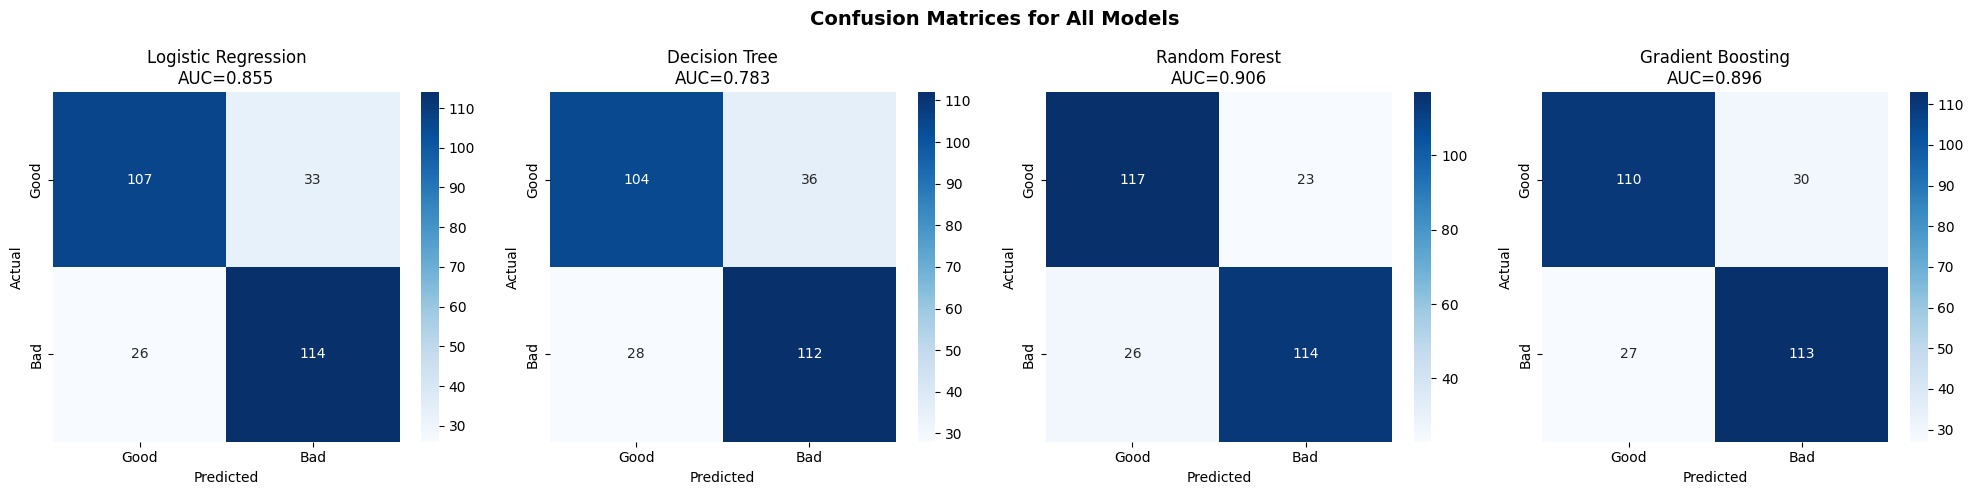

In [15]:
# Cell 15: Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    ax.set_title(f'{name}\nAUC={res["roc_auc"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices for All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

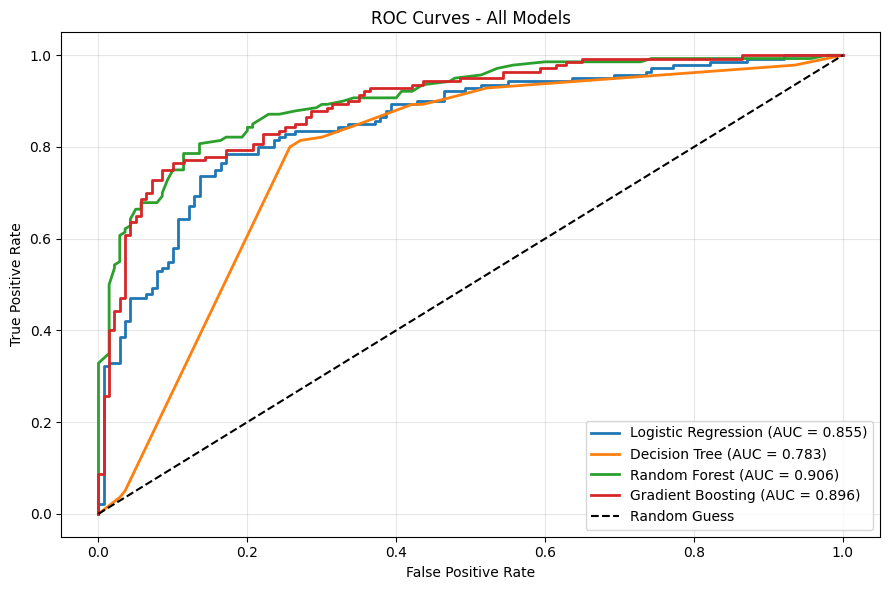

In [16]:
# Cell 16: ROC Curves for all models
plt.figure(figsize=(9, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

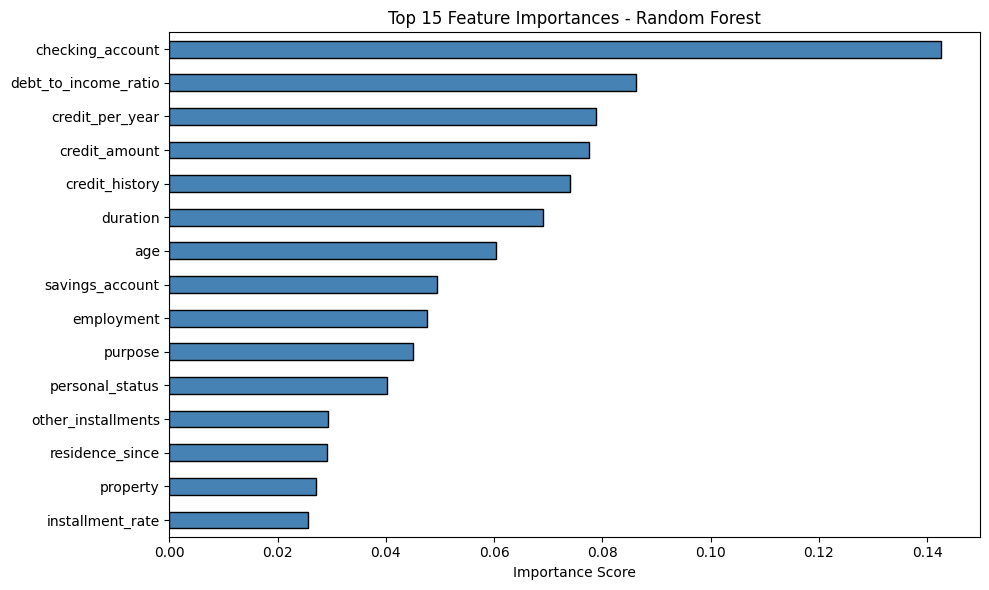

In [17]:
# Cell 17: Feature importance from Random Forest
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
# Cell 18: Predict credit score for a new applicant
sample = X_test_scaled[0].reshape(1, -1)  # Take first test sample

best_model = results['Random Forest']['model']
pred = best_model.predict(sample)[0]
prob = best_model.predict_proba(sample)[0]

print("🔍 Credit Score Prediction for Sample Applicant:")
print(f"   Prediction     : {'⚠️ BAD Credit Risk' if pred == 1 else '✅ GOOD Credit Risk'}")
print(f"   Good Credit Prob : {prob[0]*100:.2f}%")
print(f"   Bad Credit Prob  : {prob[1]*100:.2f}%")

🔍 Credit Score Prediction for Sample Applicant:
   Prediction     : ✅ GOOD Credit Risk
   Good Credit Prob : 59.00%
   Bad Credit Prob  : 41.00%


In [19]:
# Cell 19: Cross-validation for best model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_resampled, y_resampled,
                             cv=cv, scoring='roc_auc')

print("📈 5-Fold Cross-Validation (Random Forest - ROC-AUC):")
print(f"   Scores : {[round(s, 4) for s in cv_scores]}")
print(f"   Mean   : {cv_scores.mean():.4f}")
print(f"   Std    : {cv_scores.std():.4f}")
print("\n✅ Credit Scoring Model Complete!")

📈 5-Fold Cross-Validation (Random Forest - ROC-AUC):
   Scores : [np.float64(0.9401), np.float64(0.8873), np.float64(0.9215), np.float64(0.9193), np.float64(0.9159)]
   Mean   : 0.9168
   Std    : 0.0170

✅ Credit Scoring Model Complete!
